# Course 5, Module 4, Lesson 1 Screencasts

## M4L1SC1: Classification & Regression Metrics in Action

### Step 1: Getting Started with Classification Metrics

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.datasets import load_iris  # Example dataset

# Load data and split into training and testing sets
data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3, random_state=42)

# Initialize and train the model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Simulate model predictions
y_pred = model.predict(X_test)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')

print(f'Accuracy: {accuracy}, Precision: {precision}, Recall: {recall}, F1: {f1}, ROC-AUC: {roc_auc}')

Accuracy: 1.0, Precision: 1.0, Recall: 1.0, F1: 1.0, ROC-AUC: 1.0


### Step 2: Decoding Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing  # Example dataset
import numpy as np

# Load data and split into training and testing sets
data = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predicting values
y_pred = model.predict(X_test)

# Evaluate regression performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r_squared = r2_score(y_test, y_pred)

print(f'MAE: {mae}, RMSE: {rmse}, R²: {r_squared}')

MAE: 0.5272474538306174, RMSE: 0.7284008391515455, R²: 0.595770232606166


## M4L1SC2: Evaluating Generative Models: FRom Text to Images

### Step 1: Metrics for Textual Generative Models

In [ ]:
!pip install pytorch-fid --quiet

In [ ]:
from nltk.translate.bleu_score import sentence_bleu

# Sample generated sentence
reference = [['this', 'is', 'a', 'test']]
candidate = ['this', 'is', 'a', 'test']

# Calculate BLEU score
reference_bleu = sentence_bleu(reference, candidate)
print(f'BLEU Score: {reference_bleu}')


BLEU Score: 1.0


### Step 2: Evaluating Image Generative Models

In [ ]:
!pip install kaggle --quiet
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d cashbowman/ai-generated-images-vs-real-images -p data --unzip

mkdir: cannot create directory ‘/root/.kaggle’: File exists
Dataset URL: https://www.kaggle.com/datasets/cashbowman/ai-generated-images-vs-real-images
License(s): Community Data License Agreement - Sharing - Version 1.0
 98% 465M/476M [00:01<00:00, 361MB/s]
100% 476M/476M [00:01<00:00, 445MB/s]


In [ ]:
# !pip install pillow pytorch-fid --quiet
import pathlib as pl, tempfile, shutil, torch
from PIL import Image, UnidentifiedImageError
from pytorch_fid import fid_score

# ───────────── 1. Where your raw images live ─────────────
SRC_REAL      = pl.Path("data/RealArt/RealArt")
SRC_GENERATED = pl.Path("data/AiArtData/AiArtData")

# ───────────── 2. Make two temp folders with 299×299 RGB copies ─────────
tmp_root = pl.Path(tempfile.mkdtemp(prefix="fid_tmp_"))
DST_REAL      = tmp_root / "real"
DST_GENERATED = tmp_root / "generated"
DST_REAL.mkdir(), DST_GENERATED.mkdir()

def resize_folder(src: pl.Path, dst: pl.Path):
    bad = 0
    for p in src.rglob("*"):
        if p.is_file():
            try:
                with Image.open(p) as im:
                    im = im.convert("RGB").resize((299, 299), Image.BICUBIC)
                    im.save(dst / p.name, format="JPEG")
            except (UnidentifiedImageError, OSError):
                bad += 1
    print(f"{src.name}: copied {len(list(dst.iterdir()))} files "
          f"(skipped {bad} unreadable)")

resize_folder(SRC_REAL,      DST_REAL)
resize_folder(SRC_GENERATED, DST_GENERATED)

# ───────────── 3. Compute FID on the resized sets ─────────
n_real, n_gen = len(list(DST_REAL.iterdir())), len(list(DST_GENERATED.iterdir()))
batch_size    = min(64, n_real, n_gen) or 1
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fid_value = fid_score.calculate_fid_given_paths(
    [str(DST_REAL), str(DST_GENERATED)],
    batch_size=batch_size,
    device=device,
    dims=2048,     # Inception-V3 pool-3
    num_workers=0  # keep DataLoader single-process → avoids collate bug
)
print(f"FID score: {fid_value:.4f}")

# ───────────── 4. Clean-up temp folder (optional) ─────────
# shutil.rmtree(tmp_root)   # uncomment to delete resized copies

RealArt: copied 436 files (skipped 0 unreadable)
AiArtData: copied 539 files (skipped 0 unreadable)


100%|██████████| 9/9 [03:37<00:00, 24.15s/it]


FID score: 113.4832


### Step 3: Visualizing the Images

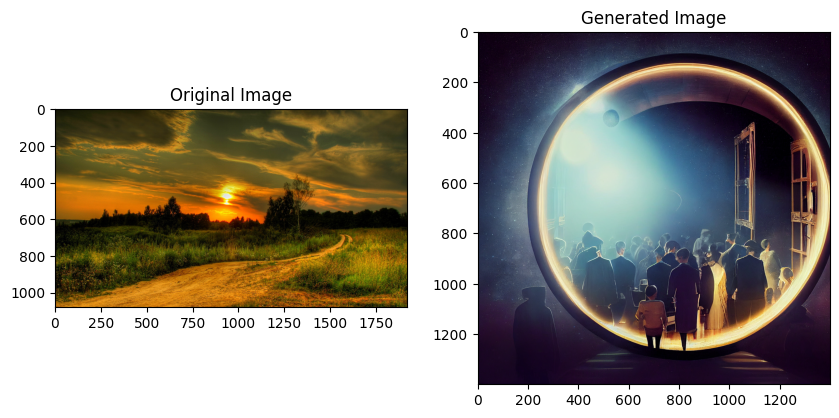

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from random import choice

real_files = [f for f in os.listdir(SRC_REAL) if os.path.isfile(os.path.join(SRC_REAL, f))]
generated_files = [f for f in os.listdir(SRC_GENERATED) if os.path.isfile(os.path.join(SRC_GENERATED, f))]


# Load images
real_image = mpimg.imread(f'data/RealArt/RealArt/{choice(real_files)}')
generated_image = mpimg.imread(f'data/AiArtData/AiArtData/{choice(generated_files)}')

# Plot images
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(real_image)
ax1.set_title('Original Image')
ax2.imshow(generated_image)
ax2.set_title('Generated Image')

plt.show()